# Project 1: Auto Insurance Claims Analysis

## Business Context
Analysis of 1,000 auto insurance claims to identify fraud predictors, high-cost segments, and risk patterns across incident types, collision types, and customer demographics.

## Dataset
- 1,000 claims across Ohio, Indiana, and Illinois
- 40 variables including incident type, severity, claim amounts, 
  and fraud flag
- Source: Kaggle Auto Insurance Claims Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('Week1/insurance_claims.csv')

print(df.shape)
print(df.head())

(1000, 40)
   months_as_customer  age  policy_number policy_bind_date policy_state  \
0                 328   48         521585       2014-10-17           OH   
1                 228   42         342868       2006-06-27           IN   
2                 134   29         687698       2000-09-06           OH   
3                 256   41         227811       1990-05-25           IL   
4                 228   44         367455       2014-06-06           IL   

  policy_csl  policy_deductable  policy_annual_premium  umbrella_limit  \
0    250/500               1000                1406.91               0   
1    250/500               2000                1197.22         5000000   
2    100/300               2000                1413.14         5000000   
3    250/500               2000                1415.74         6000000   
4   500/1000               1000                1583.91         6000000   

   insured_zip  ... police_report_available total_claim_amount injury_claim  \
0       466132

In [2]:
# Dropping empty column
df = df.drop(columns=['_c39'])

# checking missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

#checking for ? values in key columns
print(df['authorities_contacted'].value_counts())
print(df['police_report_available'].value_counts())
print(df['collision_type'].value_counts())

authorities_contacted    91
dtype: int64
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Name: count, dtype: int64
police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
?                  178
Name: count, dtype: int64


In [3]:
# Replacing ? with Unknown in text columns
df['police_report_available'] = df['police_report_available'].replace('?', 'Unknown')
df['collision_type'] = df['collision_type'].replace('?', 'Unknown')

# Filling missing authorities_contacted with Unknown
df['authorities_contacted'] = df['authorities_contacted'].fillna('Unknown')

# Verifying fixes
print(df['police_report_available'].value_counts())
print(df['collision_type'].value_counts())
print(df['authorities_contacted'].value_counts())

# Confirming no more missing values
print("\nRemaining nulls:")
print(df.isnull().sum()[df.isnull().sum() > 0])

police_report_available
Unknown    343
NO         343
YES        314
Name: count, dtype: int64
collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
Unknown            178
Name: count, dtype: int64
authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
Unknown       91
Name: count, dtype: int64

Remaining nulls:
Series([], dtype: int64)


In [4]:
# Question 1: Fraud rate by incident type 
fraud_by_type = df.groupby('incident_type')['fraud_reported'].value_counts(
    normalize=True).round(3) * 100

fraud_by_type = fraud_by_type.unstack()
print(fraud_by_type)

fraud_reported               N     Y
incident_type                       
Multi-vehicle Collision   72.8  27.2
Parked Car                90.5   9.5
Single Vehicle Collision  71.0  29.0
Vehicle Theft             91.5   8.5


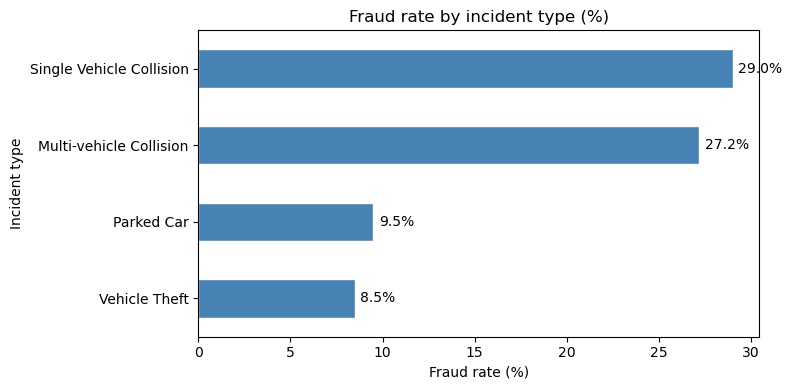

In [5]:
# Bar chart - fraud rate by incident type
ax = fraud_by_type['Y'].sort_values().plot(
    kind='barh',
    figsize=(8,4),
    color='steelblue',
    edgecolor='white')

plt.title('Fraud rate by incident type (%)')
plt.xlabel('Fraud rate (%)')
plt.ylabel('Incident type')

for i, v in enumerate(fraud_by_type['Y'].sort_values()):
    ax.text(v + 0.3, i, f'{round(v,1)}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()
         

Single vehicle collision claims have the highest fraud rate at 29.0%, followed by multi-vehicle collision at 27.2%. Parked car and vehicle theft are negligible in comparison. Collision-type incidents should be the primary focus of fraud investigation efforts. 

In [8]:
# Group severity into two categories
def categorize_severity(x):
    if x in ['Major Damage', 'Total Loss']:
        return 'Serious'
    else:
        return 'Minor'

df['severity_group'] = df['incident_severity'].apply(categorize_severity)

print(df['severity_group'].value_counts())

severity_group
Serious    556
Minor      444
Name: count, dtype: int64


In [9]:
# Total claim cost by region and severity group
regional_severity = df.groupby(['incident_state', 'severity_group'])[
    'total_claim_amount'].sum().round(0).unstack()

print(regional_severity)

severity_group    Minor  Serious
incident_state                  
NC              1965730  3455500
NY              6103440  8670330
OH               228660   916060
PA               448580  1038570
SC              4368070  9170080
VA              1477090  4022680
WV              3105090  7792060


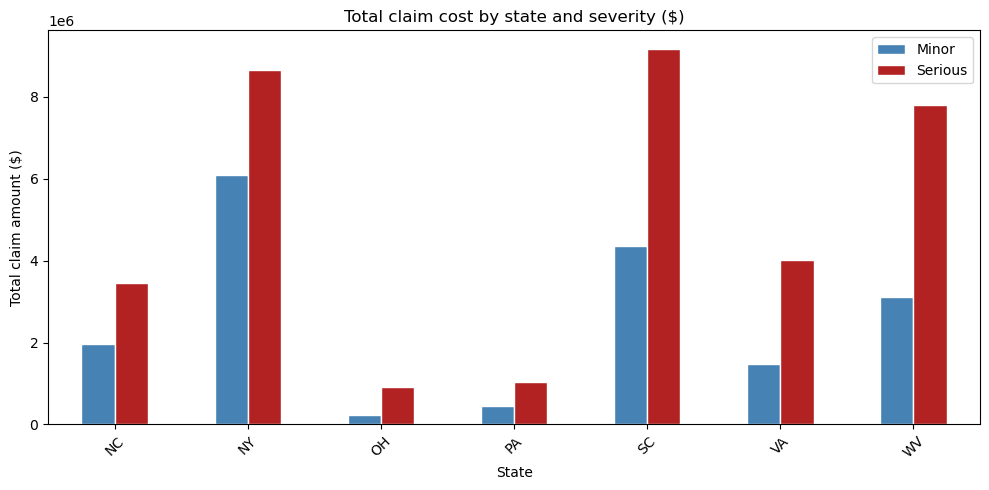

In [10]:
# Grouped bar chart - claim cost by state and severity 
regional_severity.plot(
    kind='bar',
    figsize=(10, 5),
    color=['steelblue', 'firebrick'],
    edgecolor='white')

plt.title('Total claim cost by state and severity ($)')
plt.xlabel('State')
plt.ylabel('Total claim amount ($)')
plt.xticks(rotation=45)
plt.legend(['Minor', 'Serious'])
plt.tight_layout()
plt.show()

Serious claims dominate total cost in every state. SC leads with 9.17M in serious claims followed by NY with 8.67M. 

Insurers operating in SC and NY should prioritize serious incident management and pricing review given their disproportionate claims cost. 